In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
rho_0 = 1
epsilon_0 = 1
R = 1
Alpha = 5

Q = (rho_0 * R**5) / (5 * epsilon_0 * Alpha**6) * (np.exp(Alpha) * (Alpha**5 - 5 * Alpha**4 + 20 * Alpha**3 - 60 * Alpha**2 + 120 * Alpha - 720) + 720)

In [54]:
def I1(r):
    return np.exp(Alpha * r / R) * (R * r**5 / Alpha - 5 * R**2 * r**4 / Alpha**2 + 20 * R**3 * r**3 / Alpha**3 - 60 * R**4 * r**2 / Alpha**4 + 120 * R**5 * r / Alpha**5 - 720 * R**6 / Alpha**6) + 720 * R**6 / Alpha**6

def I2(r):
    return R/Alpha * (np.exp(Alpha) - np.exp(Alpha*r/R))

def phi_int(r, theta, phi):
    p1 = rho_0/(5*epsilon_0*R)
    p2 = np.sin(theta)**2 * np.cos(2*phi)
    p3 = I1(r)/r**3 + r**2*I2(r)
    return p1*p2*p3

def phi_ext(r, theta, phi):
    return Q/r**3 * np.sin(theta)**2 * np.cos(2*phi)

def f(r):
    return (rho_0 / (5 * epsilon_0 * R)) * (I1(r) / r**3 + r**2 * I2(r))

def f_p(r):
    return (rho_0 / (5 * epsilon_0 * R)) * (-3 * I1(r) / r**4 + 2 * r * I2(r))

def E_int(r, theta, phi):
    E_r = -f_p(r) * np.sin(theta)**2 * np.cos(2*phi)
    E_theta = -f(r)/r * np.sin(2*theta) * np.cos(2*phi)
    E_phi = 2 * f(r)/r * np.sin(theta) * np.sin(2*phi)
    return [E_r, E_theta, E_phi]

def E_ext(r, theta, phi):
    E_r = 3 * Q / r**4 * np.sin(theta)**2 * np.cos(2*phi)
    E_theta = -Q / r**4 * np.sin(2*theta) * np.cos(2*phi)
    E_phi = 2 * Q / r**4 * np.sin(theta) * np.sin(2*phi)
    return [E_r, E_theta, E_phi]

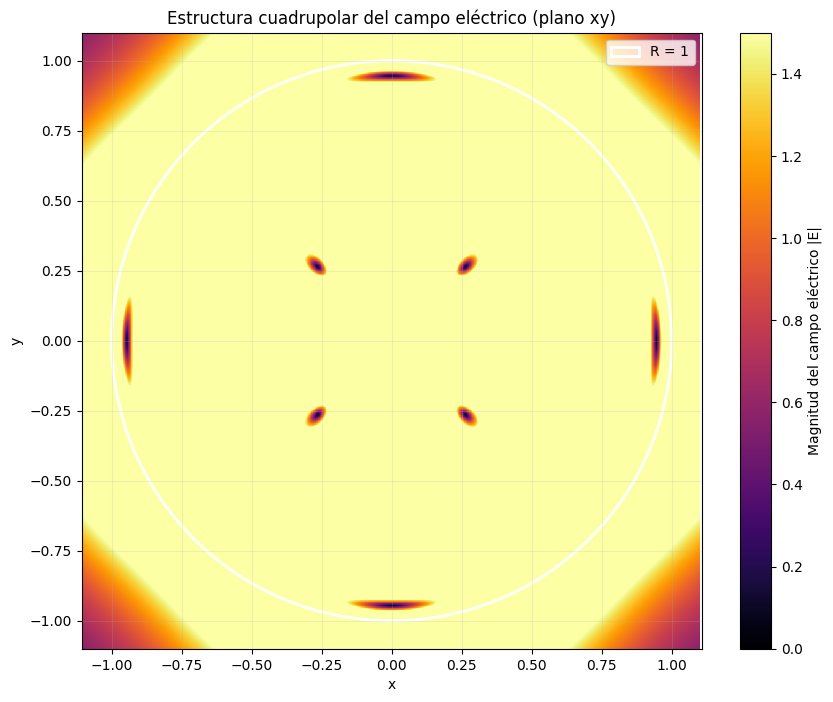

In [55]:
# --- Malla de alta resolución ---
x = np.linspace(-1.1, 1.1, 1000)  # Más puntos para capturar detalles angulares
y = np.linspace(-1.1, 1.1, 1000)
X, Y = np.meshgrid(x, y)

# --- Coordenadas esféricas (theta=pi/2 para z=0) ---
R_mag = np.sqrt(X**2 + Y**2)
Phi = np.arctan2(Y, X)

# --- Máscara para interior/exterior ---
inside = R_mag <= R
outside = ~inside

# --- Cálculo vectorizado del campo ---
E_mag = np.zeros_like(X)

# Interior (dominante para lóbulos)
r_inside = R_mag[inside]
f_inside = f(r_inside)
f_p_inside = f_p(r_inside)
E_r_in = -f_p_inside * np.cos(2 * Phi[inside])
E_phi_in = 2 * f_inside / r_inside * np.sin(2 * Phi[inside])
E_mag[inside] = np.sqrt(E_r_in**2 + E_phi_in**2)

# Exterior (decaye rápidamente, pero se incluye para completitud)
r_outside = R_mag[outside]
E_r_out = 3 * Q / r_outside**4 * np.cos(2 * Phi[outside])
E_phi_out = 2 * Q / r_outside**4 * np.sin(2 * Phi[outside])
E_mag[outside] = np.sqrt(E_r_out**2 + E_phi_out**2)

# --- Evitar singularidad en el origen ---
E_mag[R_mag < 1e-10] = 0

# --- Gráfico optimizado ---
plt.figure(figsize=(10, 8))
plt.pcolormesh(X, Y, E_mag, shading='auto', cmap='inferno', vmin=0, vmax=1.5)  # vmax ajustado para resaltar lóbulos
plt.colorbar(label='Magnitud del campo eléctrico |E|')

# --- Círculo de radio R=1 ---
circle = plt.Circle((0, 0), R, color='white', fill=False, linewidth=2, label='R = 1')
plt.gca().add_patch(circle)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Estructura cuadrupolar del campo eléctrico (plano xy)')
plt.axis('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [58]:
print(f"Q = {Q:.4f}")
print("\n")
print(f"phi_int(1, pi/4, pi/4) = {phi_int(0.5, np.pi/4, np.pi/4):.2e}")
print(f"phi_ext(1, pi/4, pi/4) = {phi_ext(0.5, np.pi/4, np.pi/4):.2e}")
print("\n")
print(f"f(1) = {f(0.5):.4f}")
print(f"f_p(1) = {f_p(0.5):.4f}")
print("\n")
print(f"E_int(1, pi/4, pi/4) = {E_int(0.5, np.pi/4, np.pi/4)}")
print(f"E_ext(1, pi/4, pi/4) = {E_ext(0.5, np.pi/4, np.pi/4)}")

Q = 1.6809


phi_int(1, pi/4, pi/4) = 2.18e-17
phi_ext(1, pi/4, pi/4) = 4.12e-16


f(1) = 0.7123
f_p(1) = 9.3493


E_int(1, pi/4, pi/4) = [np.float64(-2.8623927464361347e-16), np.float64(-8.723123025710739e-17), np.float64(2.0146802976659406)]
E_ext(1, pi/4, pi/4) = [np.float64(2.4702720293705515e-15), np.float64(-1.6468480195803679e-15), np.float64(38.035371603949244)]
